# 06 — Show what each method reveals

Create plots that emphasize the strengths of each model rather than scoring one against the other.

TEMPTED is shown as a subject-level longitudinal decomposition with subject components, temporal loading curves, and genus loadings.

MEFISTO is shown as a sample-level longitudinal decomposition with factors that can be related directly to age and other time-varying metadata.

Both models include a 1-vs-2 latent-space plot so they can be viewed beside the PCA and t-SNE plots from notebook 02.

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path(".") if Path("data").exists() else Path("..")
processed = sorted((root / "data" / "processed_16s").iterdir())[-1]
prep = sorted((root / "data" / "preprocessing").iterdir())[-1]
meta_dir = sorted((root / "data" / "metadata_analysis").iterdir())[-1]
t_dir = sorted((root / "data" / "tempted").iterdir())[-1]
m_dir = sorted((root / "data" / "mefisto").iterdir())[-1]
output = root / "data" / "figures" / datetime.now().strftime("%Y%m%d_%H%M%S")
output.mkdir(parents=True)

# load preprocessing, taxonomy, and model outputs
coords = pd.read_csv(prep / "coordinates.csv")
taxonomy = pd.read_csv(processed / "taxonomy.csv")
tempted = pd.read_csv(meta_dir / "tempted_with_metadata.csv")
mefisto = pd.read_csv(meta_dir / "mefisto_with_metadata.csv")
assoc = pd.read_csv(meta_dir / "metadata_associations.csv")
t_load = pd.read_csv(t_dir / "feature_loadings.csv")
m_load = pd.read_csv(m_dir / "feature_loadings.csv")
t_time = pd.read_csv(t_dir / "temporal_loadings.csv")

t_dims = [c for c in tempted if c.startswith("component_")]
m_dims = [c for c in mefisto if c.startswith("factor_")]

countries = ["FIN", "EST", "RUS"]
colors = {
    "FIN": "green",
    "EST": "blue",
    "RUS": "red",
}

In [2]:
# save a figure

def save(name):
    plt.tight_layout()
    plt.savefig(output / name, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


# shorten taxonomy labels

def short(value):
    return str(value).split("|")[-1].replace("g__", "")


# plot the strongest metadata associations for one model

def metadata_heatmap(method, dims):
    rows = assoc[assoc["method"] == method]

    strongest = (
        rows.groupby("metadata")["absolute_association"]
        .max()
        .nlargest(12)
        .index
    )

    table = rows[rows["metadata"].isin(strongest)].pivot(
        index="metadata",
        columns="dimension",
        values="association",
    )

    plt.figure(figsize=(max(6, .8 * len(dims)), max(4, .45 * len(table))))
    plt.imshow(table, aspect="auto", cmap="coolwarm")
    plt.colorbar(label="Association")
    plt.xticks(range(len(table.columns)), table.columns, rotation=45, ha="right")
    plt.yticks(range(len(table.index)), table.index)
    plt.title(f"{method}: strongest metadata associations")
    save(f"{method.lower()}_metadata_heatmap.png")

## TEMPTED

The first plots show the subject-level component space directly. The 1-vs-2 country plot is designed to sit beside the PCA and t-SNE country plots from notebook 02.

The temporal loading curves are unique to TEMPTED and show how each component changes over the longitudinal time axis.

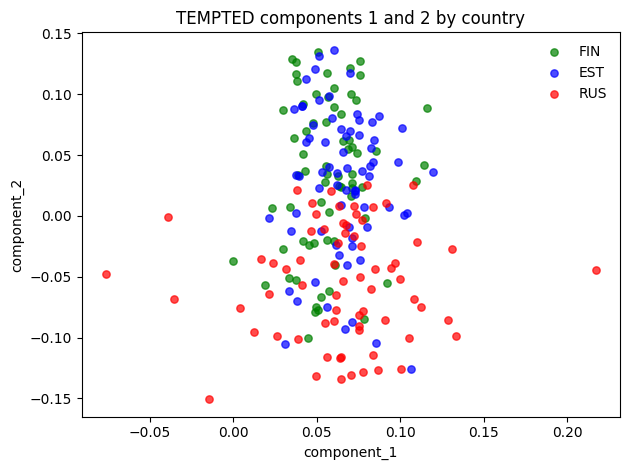

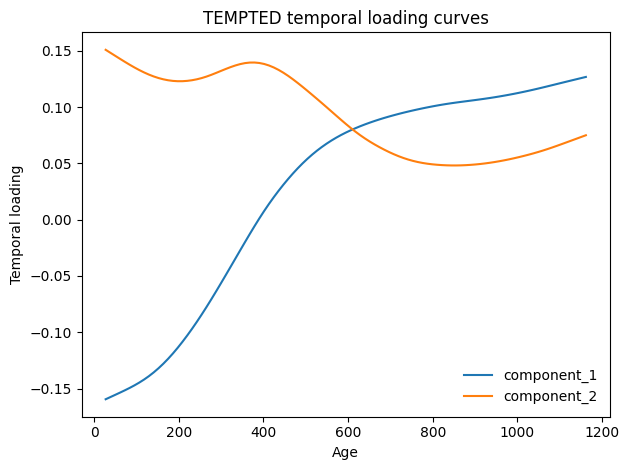

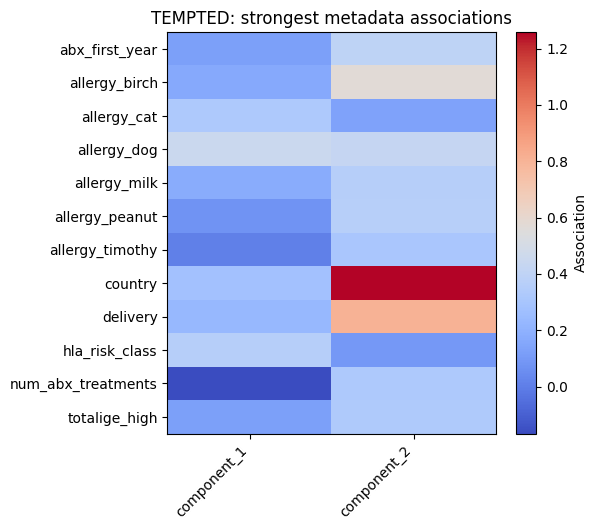

In [3]:
# plot component 1 vs component 2 by country

if len(t_dims) >= 2:
    for country in countries:
        rows = tempted["country"] == country

        plt.scatter(
            tempted.loc[rows, t_dims[0]],
            tempted.loc[rows, t_dims[1]],
            s=28,
            alpha=.7,
            label=country,
            color=colors[country],
        )

    plt.xlabel(t_dims[0])
    plt.ylabel(t_dims[1])
    plt.legend(frameon=False)
    plt.title("TEMPTED components 1 and 2 by country")
    save("tempted_components_1_2_country.png")


# plot tempted temporal loading curves

for dim in t_dims:
    plt.plot(
        t_time["time"],
        t_time[dim],
        label=dim,
    )

plt.xlabel("Age")
plt.ylabel("Temporal loading")
plt.legend(frameon=False)
plt.title("TEMPTED temporal loading curves")
save("tempted_temporal_loadings.png")


# show metadata relationships in the subject components

metadata_heatmap("TEMPTED", t_dims)

## MEFISTO

The first plot shows Factor 1 vs Factor 2 by country using the same colors as PCA, t-SNE, and TEMPTED.

The age plots highlight MEFISTO's strength as a sample-level model with factors defined for each longitudinal observation.

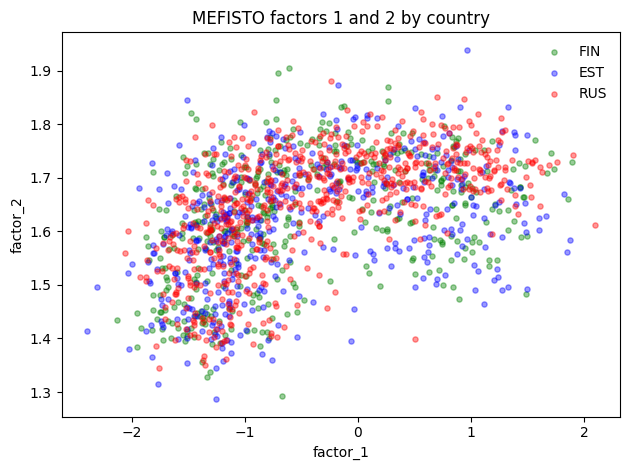

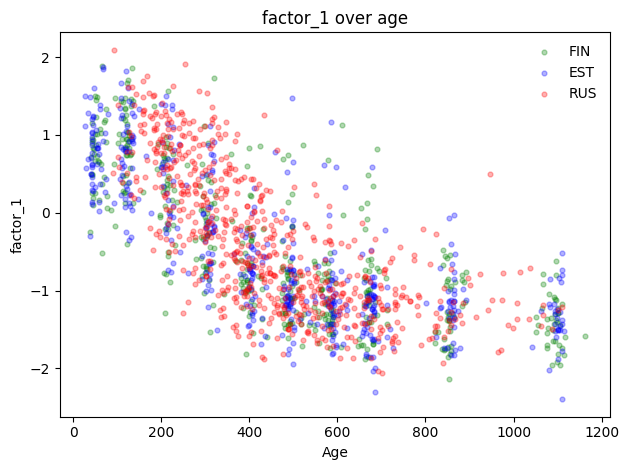

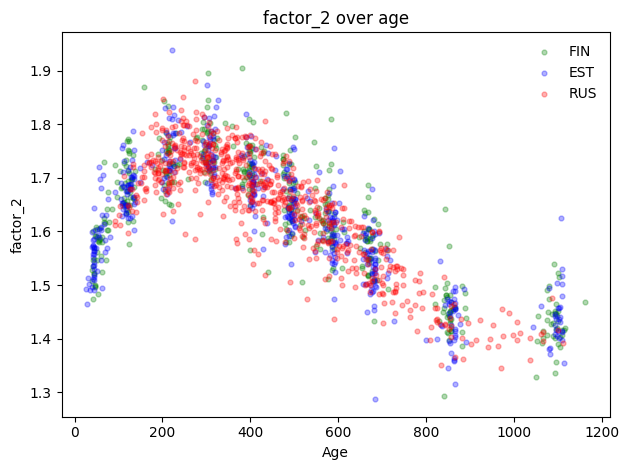

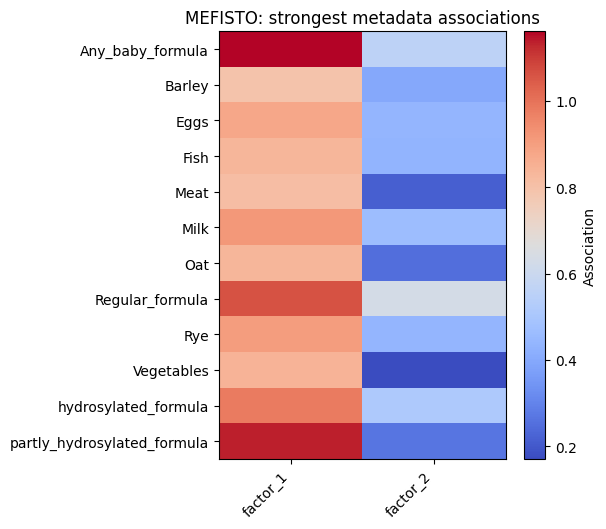

In [4]:
# plot factor 1 vs factor 2 by country

if len(m_dims) >= 2:
    for country in countries:
        rows = mefisto["country"] == country

        plt.scatter(
            mefisto.loc[rows, m_dims[0]],
            mefisto.loc[rows, m_dims[1]],
            s=14,
            alpha=.4,
            label=country,
            color=colors[country],
        )

    plt.xlabel(m_dims[0])
    plt.ylabel(m_dims[1])
    plt.legend(frameon=False)
    plt.title("MEFISTO factors 1 and 2 by country")
    save("mefisto_factors_1_2_country.png")


# plot every mefisto factor over age

for dim in m_dims:
    for country in countries:
        rows = mefisto["country"] == country

        plt.scatter(
            mefisto.loc[rows, "age"],
            mefisto.loc[rows, dim],
            s=12,
            alpha=.3,
            label=country,
            color=colors[country],
        )

    plt.xlabel("Age")
    plt.ylabel(dim)
    plt.legend(frameon=False)
    plt.title(f"{dim} over age")
    save(f"mefisto_{dim}_age.png")


# show metadata relationships in the sample factors

metadata_heatmap("MEFISTO", m_dims)

## Genus loadings

These plots show which genera contribute most strongly to each component or factor.

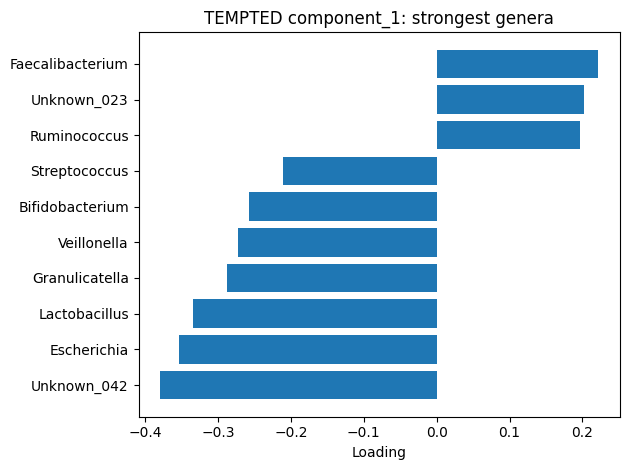

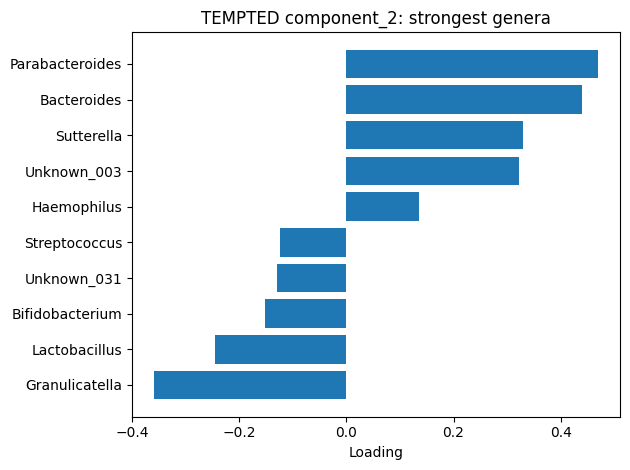

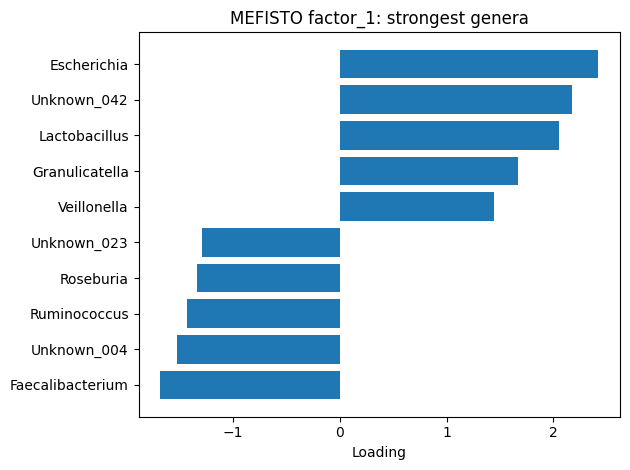

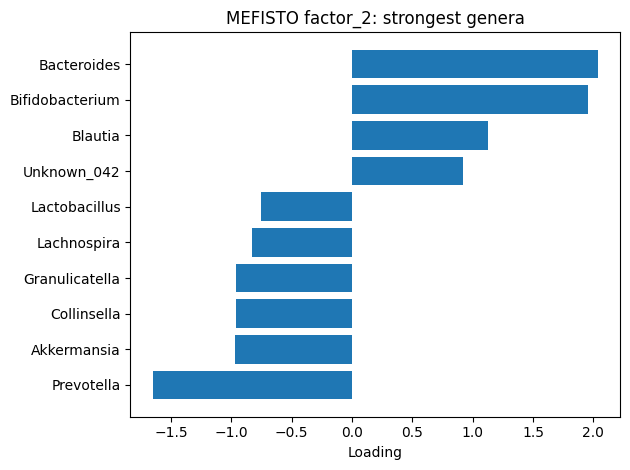

In [5]:
# plot the strongest genus loadings for each dimension

for method, loadings, dims in [
    ("TEMPTED", t_load, t_dims),
    ("MEFISTO", m_load, m_dims),
]:
    for dim in dims:
        top = loadings[["feature_id", dim]].copy()
        top["abs"] = top[dim].abs()
        top = top.nlargest(10, "abs").sort_values(dim)

        plt.barh(
            [short(x) for x in top["feature_id"]],
            top[dim],
        )

        plt.xlabel("Loading")
        plt.title(f"{method} {dim}: strongest genera")
        save(f"{method.lower()}_{dim}_top_genera.png")

## Circular Greengenes taxonomy plots

The taxonomy table comes from notebook 01, which is the single authoritative taxonomy source. Each plot keeps only the genera present in that model's loadings.


In [6]:
from matplotlib.colors import Normalize

def taxonomy_ring(loadings, dims, title, filename, top=None):

    # keep taxonomy for the genera used by this model
    model_taxonomy = taxonomy[
        taxonomy["feature"].isin(loadings["feature_id"])
    ]

    # join taxonomy to the model loadings
    table = loadings.merge(
        model_taxonomy,
        left_on="feature_id",
        right_on="feature",
    )

    # rank genera by their strongest loading
    table["importance"] = table[dims].abs().max(axis=1)

    if top:
        table = table.nlargest(
            min(top, len(table)),
            "importance",
        )

    # define the taxonomy levels
    ranks = [
        "kingdom",
        "phylum",
        "class",
        "order",
        "family",
        "genus",
    ]

    # make taxonomy paths
    paths = {}

    for row in table[["feature_id"] + ranks].itertuples(
        index=False,
        name=None,
    ):
        feature = row[0]
        path = tuple(str(x) for x in row[1:])
        paths[feature] = path

    # build the taxonomy tree
    children = {(): set()}

    for path in paths.values():
        for depth in range(1, len(ranks) + 1):
            parent = path[:depth - 1]
            node = path[:depth]

            children.setdefault(parent, set()).add(node)
            children.setdefault(node, set())

    # place genera evenly at the center of each ring cell
    tips = sorted(set(paths.values()))
    width = 2 * np.pi / len(tips)

    tip_angle = {
        tip: width * (i + .5)
        for i, tip in enumerate(tips)
    }

    # find all descendant genus angles for each taxonomy node
    def descendants(node):
        if node in tip_angle:
            return [tip_angle[node]]

        return sum(
            (descendants(child) for child in children[node]),
            [],
        )

    # place each taxonomy node at the center of its descendants
    angle = {}

    for node in children:
        a = descendants(node)

        if a:
            angle[node] = (
                np.angle(
                    np.mean(
                        np.exp(1j * np.array(a))
                    )
                )
                % (2 * np.pi)
            )

    # keep the taxonomy tree compact
    radius = {
        node: .06 + .28 * len(node) / len(ranks)
        for node in children
    }

    # set the loading color scale
    values = table.set_index("feature_id")

    limit = np.nanmax(
        np.abs(
            values[dims].to_numpy()
        )
    )

    # use a linear loading color scale
    norm = Normalize(
        vmin=-limit,
        vmax=limit,
    )

    cmap = plt.get_cmap("RdBu_r")

    # make a large figure for readable labels
    fig, ax = plt.subplots(
        figsize=(14, 14),
        subplot_kw={"projection": "polar"},
    )

    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_axis_off()

    # keep the loading rings thin and close to the labels
    ring_start = .62
    ring_width = .085

    ax.set_ylim(
        0,
        ring_start + len(dims) * ring_width + .20,
    )

    # draw the taxonomy tree
    for parent, kids in children.items():

        if parent not in angle or not kids:
            continue

        parent_angle = angle[parent]
        parent_radius = radius[parent]

        kids = sorted(kids)

        child_angles = np.array([
            angle[child]
            for child in kids
        ])

        unwrapped = (
            parent_angle
            + np.angle(
                np.exp(
                    1j * (child_angles - parent_angle)
                )
            )
        )

        # draw the branch joining sibling taxa
        if len(unwrapped) > 1:
            arc = np.linspace(
                unwrapped.min(),
                unwrapped.max(),
                25,
            )

            ax.plot(
                arc,
                np.full_like(arc, parent_radius),
                color="black",
                lw=.8,
            )

        # draw branches to the children
        for child, child_angle in zip(
            kids,
            unwrapped,
        ):
            ax.plot(
                [child_angle, child_angle],
                [parent_radius, radius[child]],
                color="black",
                lw=.8,
            )

    # match taxonomy tips back to feature IDs
    feature_for_tip = {
        path: feature
        for feature, path in paths.items()
    }

    # draw genus labels and loading rings
    for tip in tips:

        # use the same centered angle for tree, label, and ring cell
        a = tip_angle[tip]

        label = (
            str(tip[-1])
            .replace("g__", "")
        )

        degrees = np.degrees(a) % 360

        # keep all labels moving around the circle in the same direction
        rotation = 90 - degrees

        # draw large bold genus labels
        ax.text(
            a,
            .35,
            label,
            rotation=rotation,
            rotation_mode="anchor",
            ha="left",
            va="center",
            fontsize=12,
            fontweight="bold",
        )

        feature = feature_for_tip[tip]

        # draw one centered ring cell for each component or factor
        for j, dim in enumerate(dims):

            value = values.loc[
                feature,
                dim,
            ]

            ax.bar(
                a,
                ring_width,
                width=width,
                bottom=ring_start + j * ring_width,
                color=cmap(norm(value)),
                edgecolor="black",
                lw=.5,
                align="center",
            )

    # add title
    ax.set_title(
        title,
        fontsize=16,
        pad=20,
    )

    # add loading scale
    fig.colorbar(
        plt.cm.ScalarMappable(
            norm=norm,
            cmap=cmap,
        ),
        ax=ax,
        pad=.05,
        fraction=.03,
        label="Loading",
    )

    # explain ring order
    fig.text(
        .5,
        .025,
        "Rings run inner to outer in this order: "
        + ", ".join(dims),
        ha="center",
        fontsize=11,
    )

    save(filename)

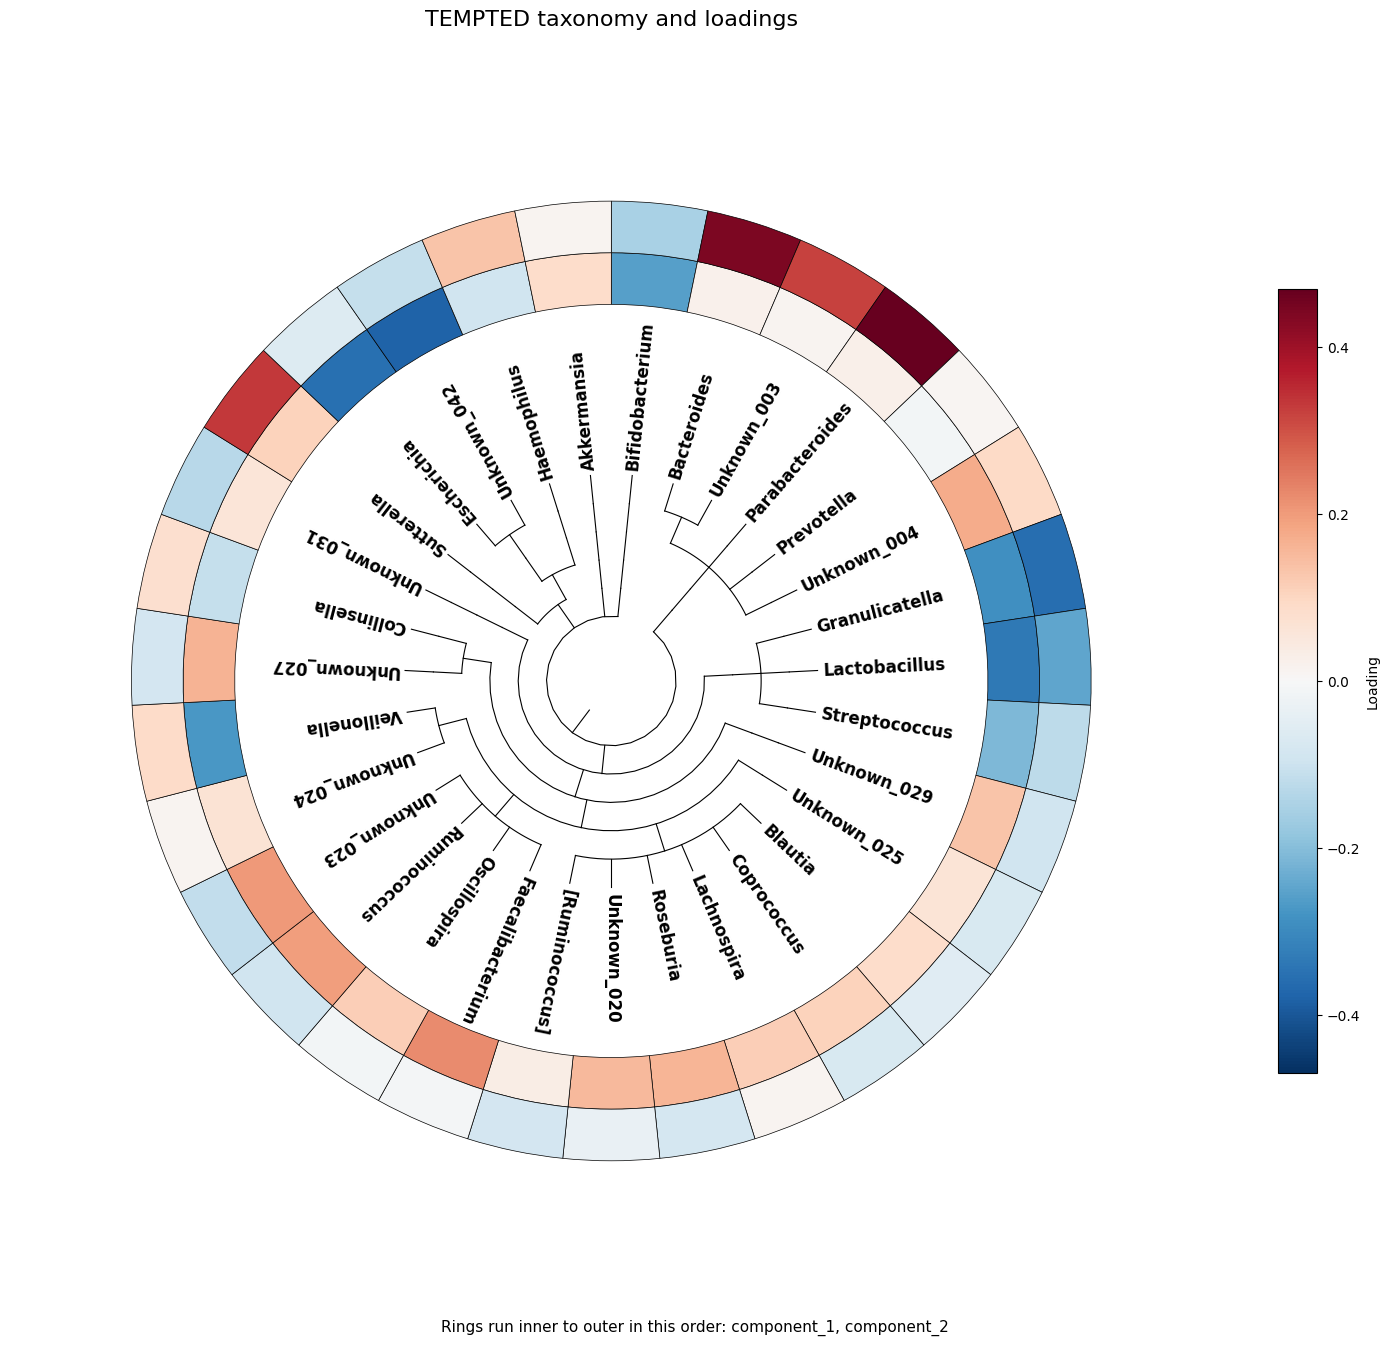

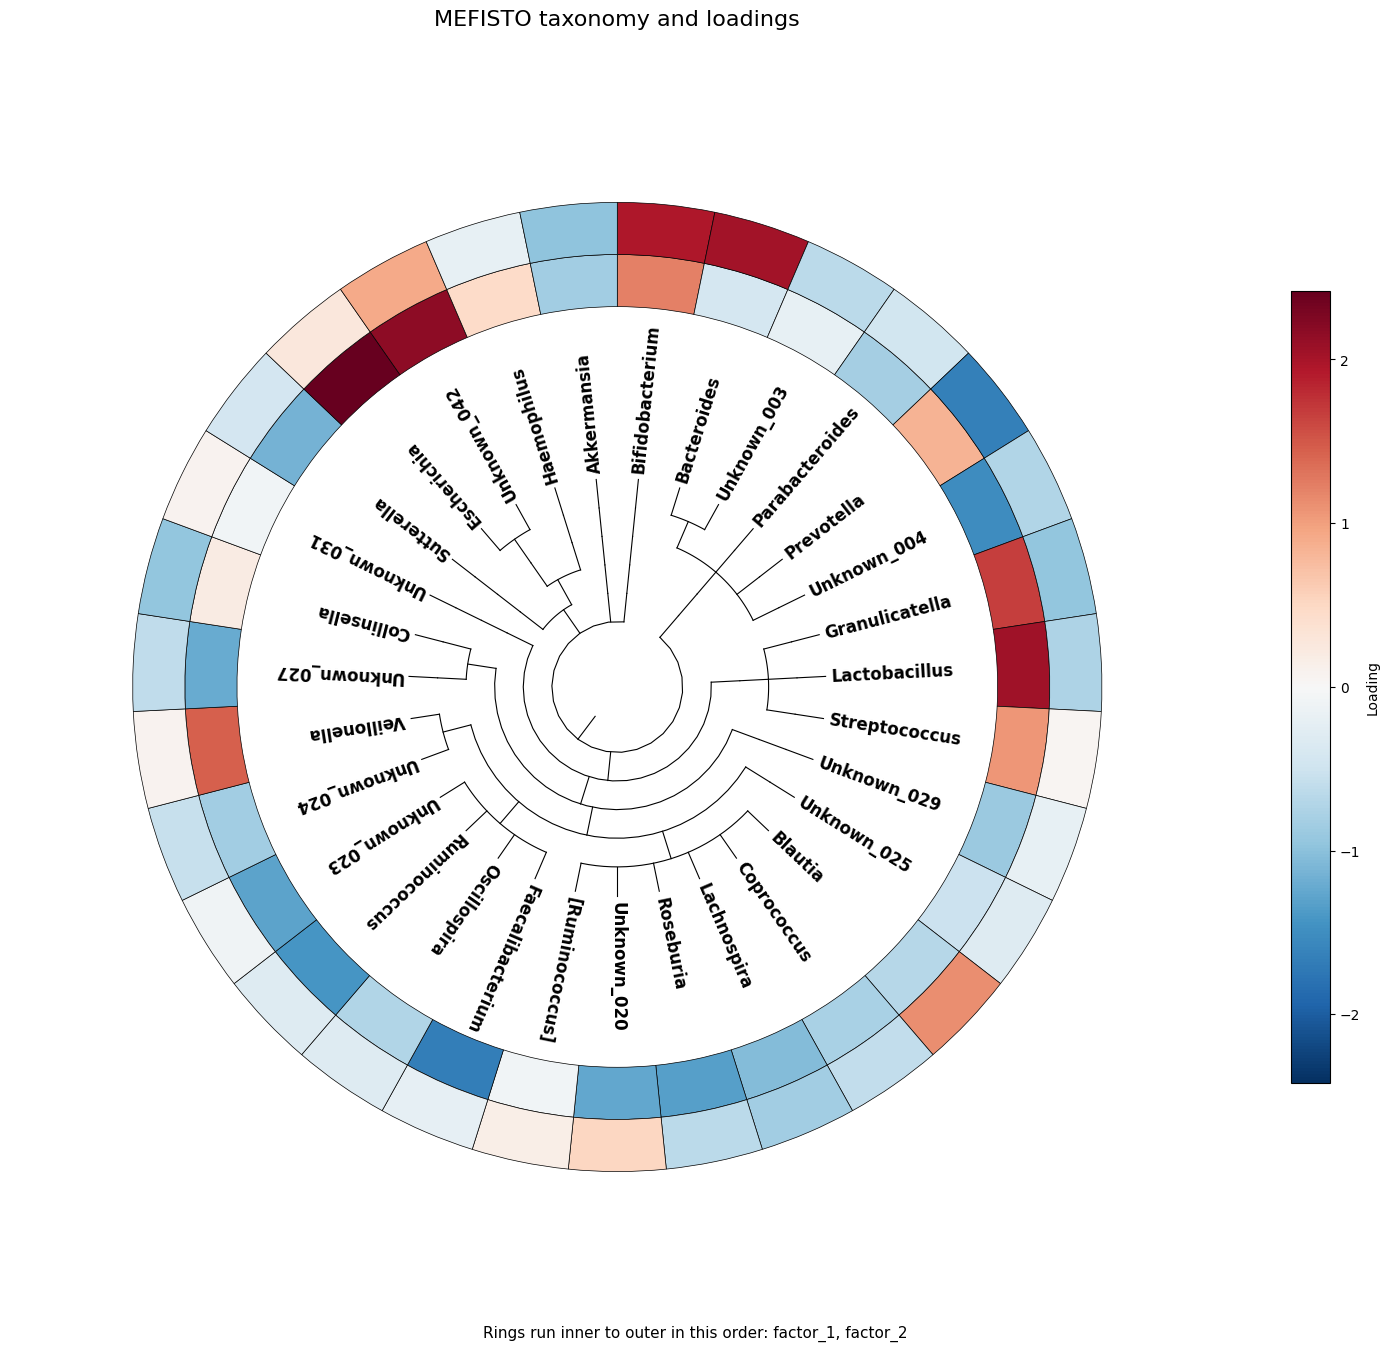

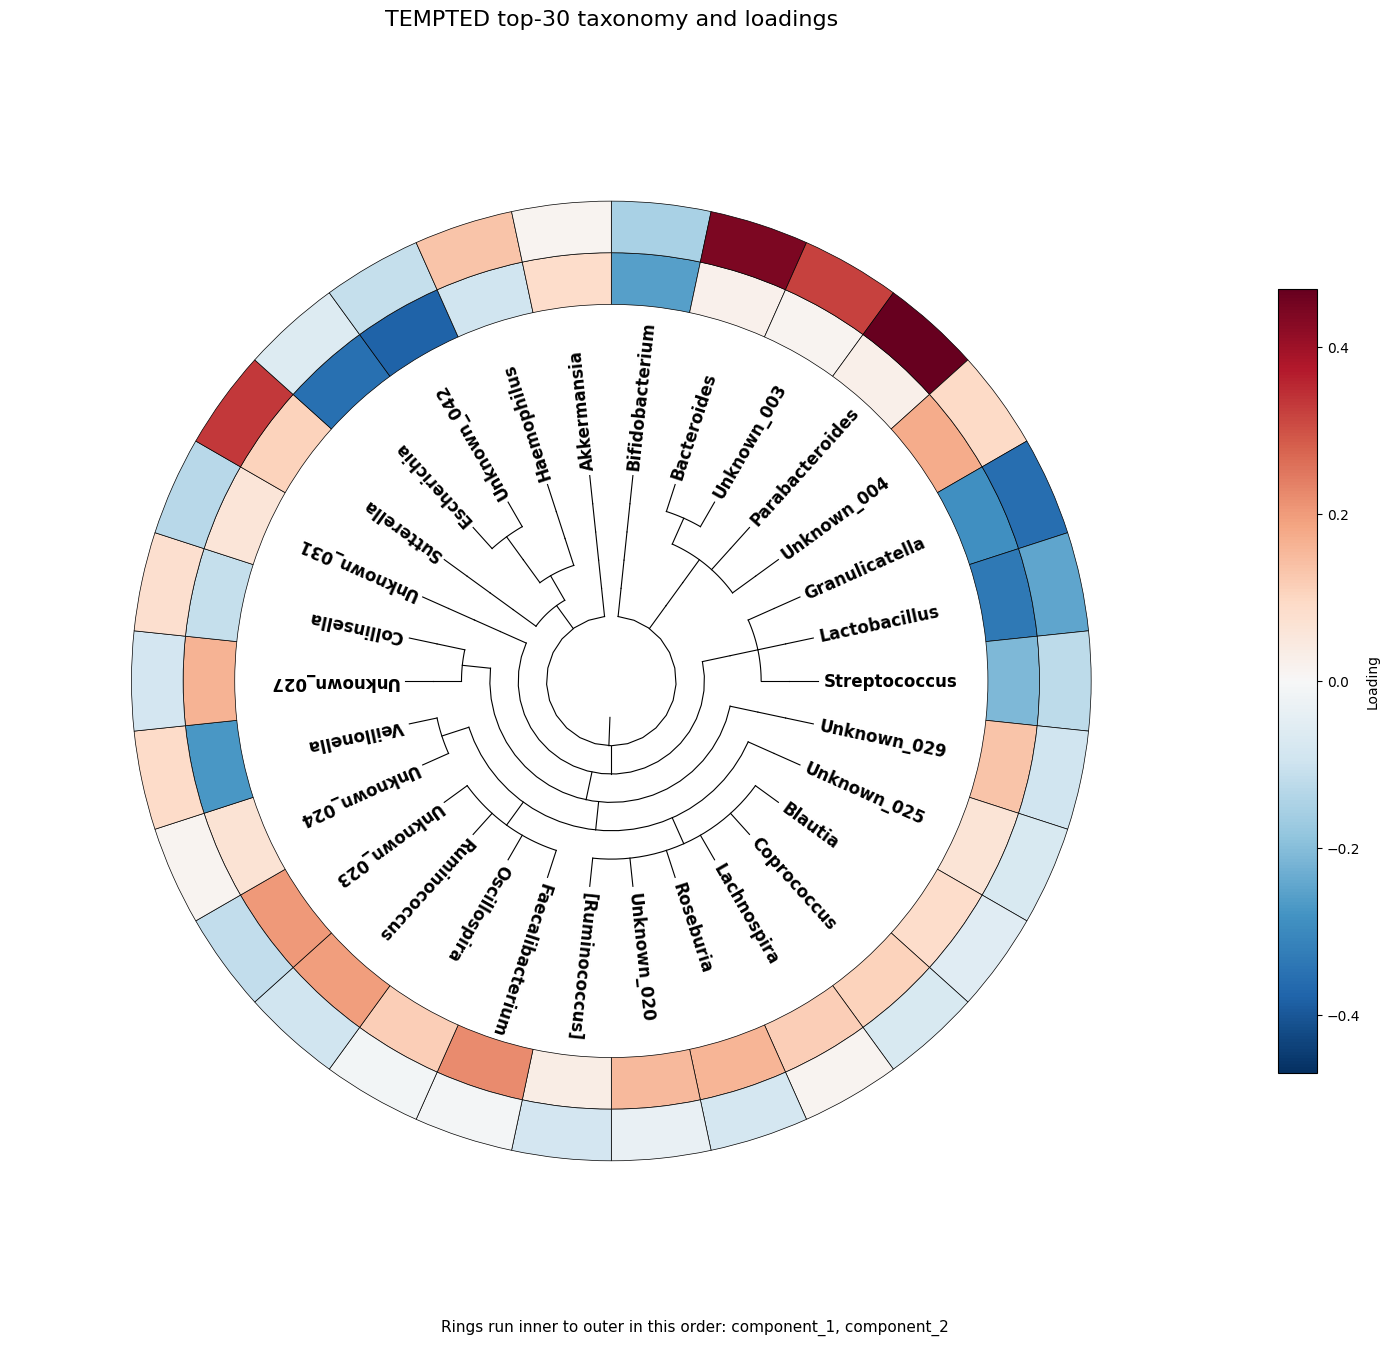

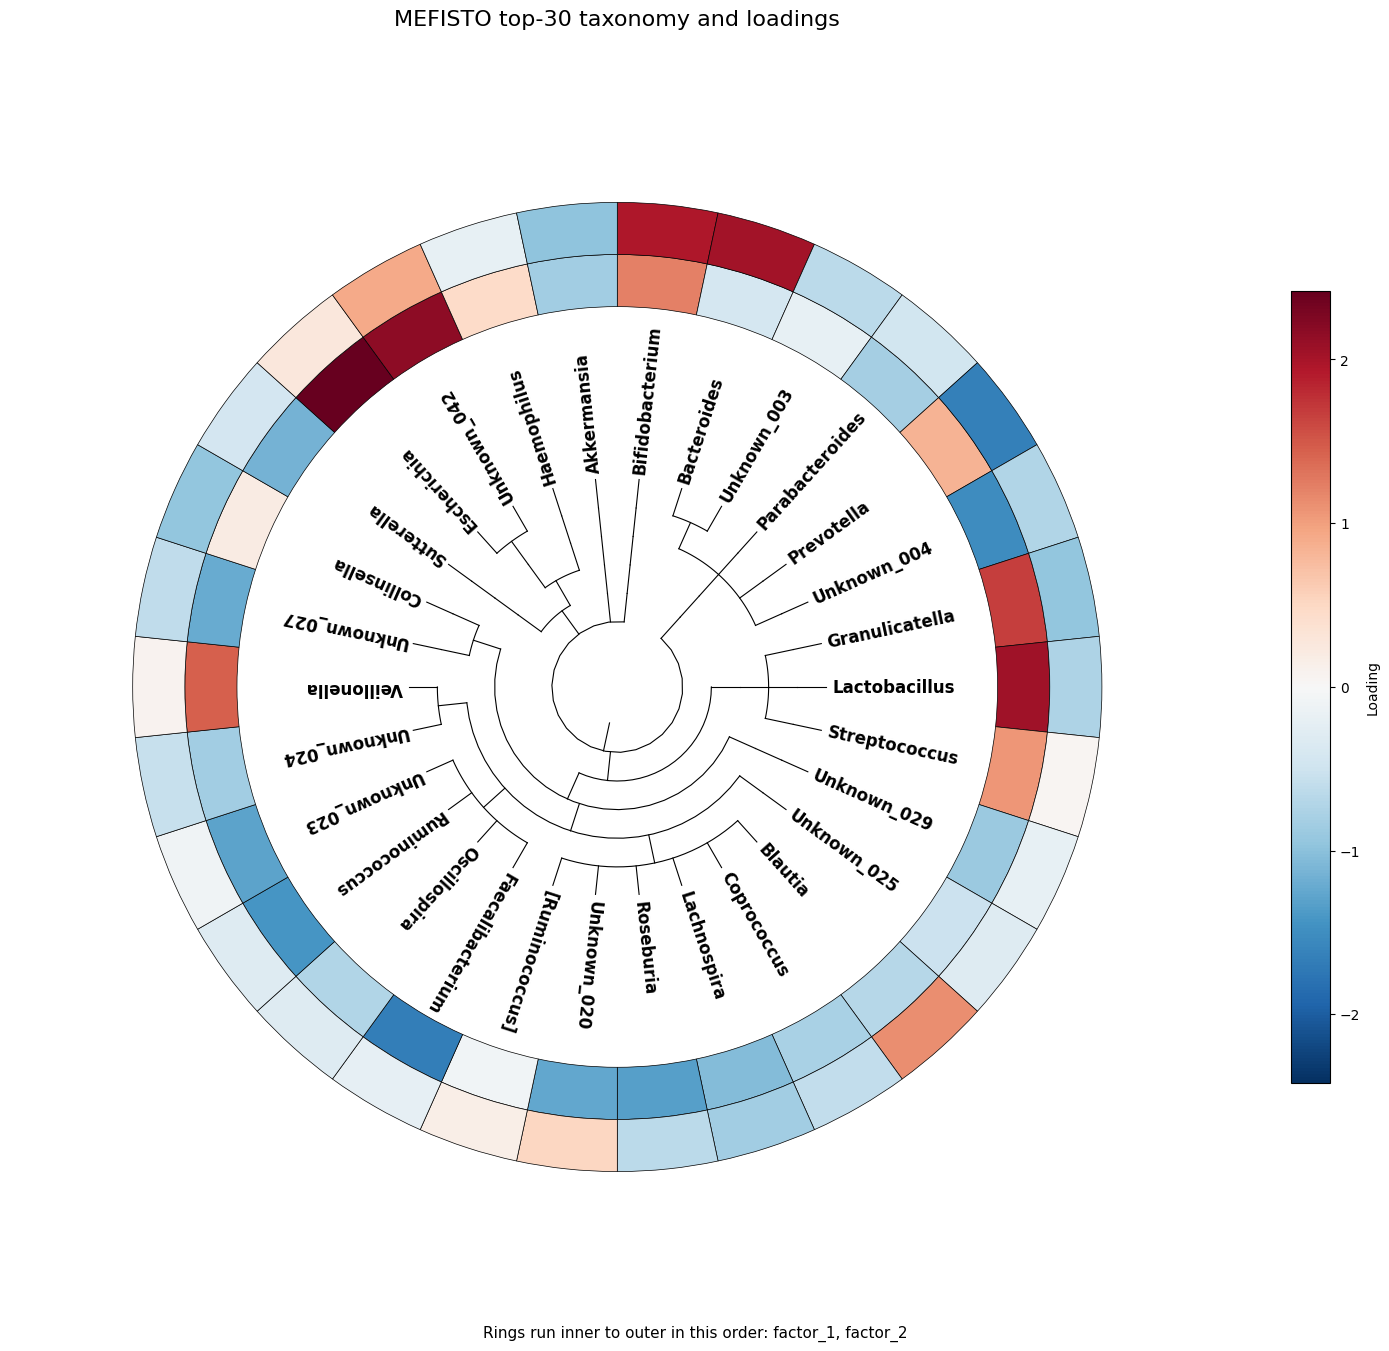

Saved: ../data/figures/20260812_022044


In [7]:
# draw full and top-30 taxonomy loading plots

taxonomy_ring(
    t_load,
    t_dims,
    "TEMPTED taxonomy and loadings",
    "tempted_taxonomy_ring.png",
)

taxonomy_ring(
    m_load,
    m_dims,
    "MEFISTO taxonomy and loadings",
    "mefisto_taxonomy_ring.png",
)

taxonomy_ring(
    t_load,
    t_dims,
    "TEMPTED top-30 taxonomy and loadings",
    "tempted_taxonomy_ring_top30.png",
    top=30,
)

taxonomy_ring(
    m_load,
    m_dims,
    "MEFISTO top-30 taxonomy and loadings",
    "mefisto_taxonomy_ring_top30.png",
    top=30,
)

print("Saved:", output)